# KEN PROTOTYPE 1.0 Model

## SINGLE scenario run file

In [1]:
############################################
# SCENARIO SWITCHES
# Are passed on to .calibration.py file
############################################
scenario_config = {
    'Baseline_scenario':                False,
    'Vision_2030_scenario':             False,
    'Transformation_scenario':          True,
    'Zero_growth_rates_steady_state':   False
}

# Import the appropriate ModelParameters class based on scenario
if scenario_config['Baseline_scenario']:
    from model.parameters_baseline import ModelParameters
elif scenario_config['Vision_2030_scenario']:
    from model.parameters_Vision2030_scenario import ModelParameters
elif scenario_config['Transformation_scenario']:
    from model.parameters_transformation_scenario import ModelParameters
elif scenario_config['Zero_growth_rates_steady_state']:
    from model.parameters_zero_growth_steadystate_calibration import ModelParameters
else:
    from model.parameters_baseline import ModelParameters


In [2]:
%reload_ext autoreload
%autoreload 2
from model.model import run_model, ModelConfig
from model.calibration import ParametersCalibrated
import model.postprocessing as post
import model.postprocessing_energy as post_energy
from statsmodels.tsa.ar_model import AutoReg
import ruptures as rpt
import numpy as np
import pandas as pd
import warnings
# Set Display Options for Full Output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## Normal simulation

This will run a simulation of the model, using inputs from `configuration.py` and `input_data`.

In [3]:
# Load and calibrate parameters
verbose = False
parameters = ModelParameters.default_values()
parameters_calibrated = pc = ParametersCalibrated(parameters, scenario_config=scenario_config, verbose=verbose)
startyear = 1
endyear = 41    # If you change endyear, also update it in the postprocessing files
config = ModelConfig(parameters, parameters_calibrated, endyear)
from model.ar_model_estimation import estimate_ar_model, estimate_ar_model_log, estimate_ar_model_growthrates, forecast, determine_optimal_lag_order, determine_optimal_lag_order_log, determine_optimal_lag_order_growthrates, identify_structural_break
from model.endogenize_input_output_matrix_A import endogenize_input_output_matrix_A
from model.energy_module import energy_module
from model.investment_module import investment_module
from model.exports_module import exports_module

c:\Users\MIESSMG\KEN_model_public\model\calibration.py:210: RuntimeWarning: divide by zero encountered in divide
  np.isinf(self.X_ / self.Y_), 0, self.X_ / self.Y_)
c:\Users\MIESSMG\KEN_model_public\model\water_module.py:324: RuntimeWarning: invalid value encountered in scalar divide
  intensity = withdrawal / output_tech_1000sar


In [4]:
# Suppress divide-by-zero warnings (numeric edge cases in sectors with zero output)
np.seterr(divide='ignore', invalid='ignore')
# Set to ignore all WARNINGS
parameters.Warnings_ON = False
df_energy = pd.read_csv("input_data/energy_intensities_for_model_only_2.csv", index_col=0, header=0).to_numpy()[0] 

In [5]:
# Run simulation
results = run_model(config)


v.Y_growth_rate_forecast[t] 0.19050854100449066 time  1
v.Y_growth_rate_forecast[t] 0.26816194169624863 time  2
v.Y_growth_rate_forecast[t] 0.06920161812745543 time  3
v.Y_growth_rate_forecast[t] 0.06792687857646323 time  4
v.Y_growth_rate_forecast[t] 0.06542697563403946 time  5
v.Y_growth_rate_forecast[t] 0.06533604885939914 time  6
v.Y_growth_rate_forecast[t] 0.07104210761642762 time  7
v.Y_growth_rate_forecast[t] 0.0683803119801827 time  8
v.Y_growth_rate_forecast[t] 0.06452121840419354 time  9
v.Y_growth_rate_forecast[t] 0.06765811257949388 time  10
v.Y_growth_rate_forecast[t] 0.0670058965286701 time  11
v.Y_growth_rate_forecast[t] 0.06255064233628599 time  12
v.Y_growth_rate_forecast[t] 0.05807440481097812 time  13
v.Y_growth_rate_forecast[t] 0.0522850547150608 time  14
v.Y_growth_rate_forecast[t] 0.049589706714743546 time  15
v.Y_growth_rate_forecast[t] 0.04704489451783867 time  16
v.Y_growth_rate_forecast[t] 0.03983084579759151 time  17
v.Y_growth_rate_forecast[t] 0.046353302425

## Macro results: Table

In [6]:
print("VALIDATION BY GROWTH RATES comparison model to data")
print(f"This is the average empirical GDP growth rate from 2013-2023 in %: {parameters_calibrated.gGY_avg*100:.2f}%")
df = results.macro.copy()
df['gY'] = df['Y'].pct_change()*100
df['gIM'] = df['IM'].pct_change()
Y_startyear =results.macro.loc[1,'Y'] 
Y_endyear = results.macro.loc[:, 'Y'].iloc[-1] 
years = endyear - startyear 
Y_avg_growth_rate_model = (Y_endyear / Y_startyear) ** (1 / years) - 1  
print(f"This is average MODEL GDP growth by taking first and last value: {Y_avg_growth_rate_model * 100:.2f}%")
print(f"This is the average MODEL GDP growth rates over the whole time horizon: {df['gY'].mean():.2f}%")

print("")
print("Model output growth rates (geometric mean, first to last value) -- same convention as COMPARE file:")
for var, label in [
    ('C',       'Consumption (C)'),
    ('I_total', 'Investment total (I_total)'),
    ('EX',      'Exports (EX)'),
    ('IM',      'Imports (IM)'),
    ('P',       'Profits (P)'),
    ('Gov_exp', 'Government expenditures (Gov_exp)'),
    ('YD_wage', 'Disposable wage income (YD_wage)'),
]:
    start_val = df.loc[1, var]
    end_val = df[var].iloc[-1]
    gr = (end_val / start_val) ** (1 / years) - 1
    print(f"  {label}: {gr*100:.2f}%")

print("")
print("For reference: Exogenous calibrated growth rate parameters (model INPUTS 2013-2023, not output results):")
print(f"  Investment private, gI_avg (calibrated trend growth rate): {parameters_calibrated.gI_avg*100:.2f}%")
print(f"  Average investment growth in desalination capacity until 2030: {parameters_calibrated.gDesalCap_avg*100:.2f}%")
print(f"  Exports oil, gEXP_oil_avg + oil growth adjustment parameter: {(parameters_calibrated.gEXP_oil_avg + parameters.oil_growth_adjustment)*100:.2f}%")
print(f"  Exports non-oil, gEXP_non_oil_avg incl. exogenous adjustment factor: {(parameters_calibrated.gEXP_non_oil_avg + parameters.non_oil_export_growth_adjustment)*100:.2f}%")
print(f"  Wages, gW + wage population growth adjustment parameter: {((df['gW'].mean() + parameters.wage_population_growth_adjustment)*100):.2f}%")
print(f"  Imports, arithmetic mean of period growth rates: {((df['gIM']).mean()*100):.2f}%")
print(f"  Government consumption gGY_avg: {((parameters_calibrated.gGY_avg*100)):.2f}%")

print("")
print("For reference: Exogenous time-series forecast growth rates (model INPUT drivers, not output results):")
print("  MEAN Y GDP growth_rate_forecast:", (df['Y_growth_rate_forecast'].mean()*100).round(1), '%')
print("  MEAN OIL_growth_rate_forecast incl. OIL growth adjustment:", (df['Oil_growth_rate_forecast'].mean()*100 + parameters.oil_growth_adjustment*100).round(1), '%')
print("  MEAN NON Oil_growth_rate_forecast incl. NON oil growth adjustment:", (df['Exports_nonoil_growth_rate_forecast'].mean()*100 + parameters.non_oil_export_growth_adjustment*100).round(1), '%')
print("  MEAN GY_growth_rate_forecast:", (df['GY_growth_rate_forecast'].mean()*100).round(1), '%')

VALIDATION BY GROWTH RATES comparison model to data
This is the average empirical GDP growth rate from 2013-2023 in %: 2.66%
This is average MODEL GDP growth by taking first and last value: 3.62%
This is the average MODEL GDP growth rates over the whole time horizon: 3.62%

Model output growth rates (geometric mean, first to last value) -- same convention as COMPARE file:
  Consumption (C): 3.74%
  Investment total (I_total): 4.88%
  Exports (EX): 3.76%
  Imports (IM): 5.22%
  Profits (P): 2.48%
  Government expenditures (Gov_exp): 3.25%
  Disposable wage income (YD_wage): 4.61%

For reference: Exogenous calibrated growth rate parameters (model INPUTS 2013-2023, not output results):
  Investment private, gI_avg (calibrated trend growth rate): 4.45%
  Average investment growth in desalination capacity until 2030: 10.00%
  Exports oil, gEXP_oil_avg + oil growth adjustment parameter: -0.23%
  Exports non-oil, gEXP_non_oil_avg incl. exogenous adjustment factor: 2.90%
  Wages, gW + wage pop

## Macro results: Plots

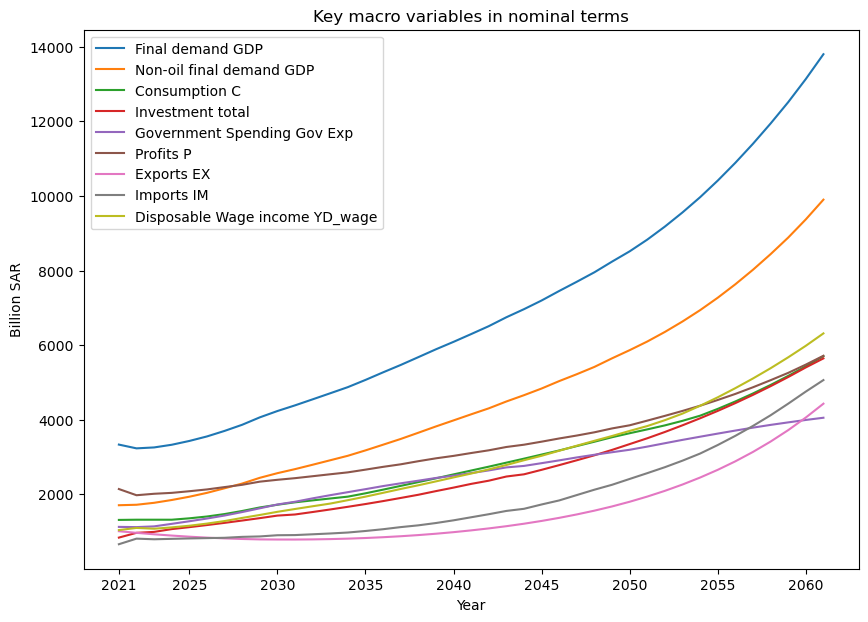

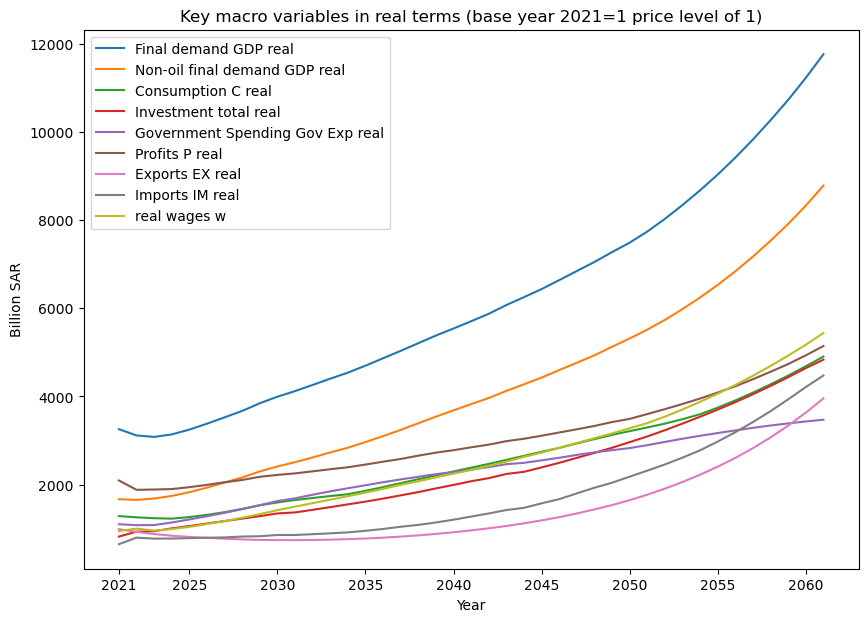

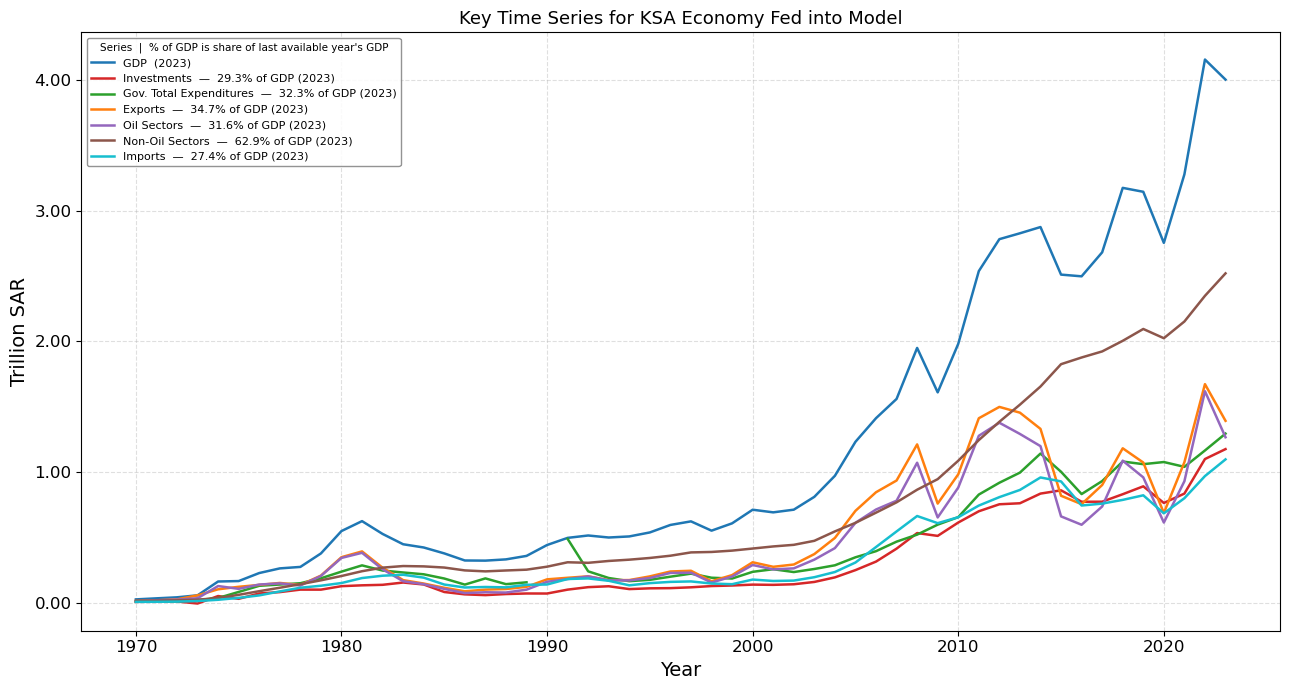

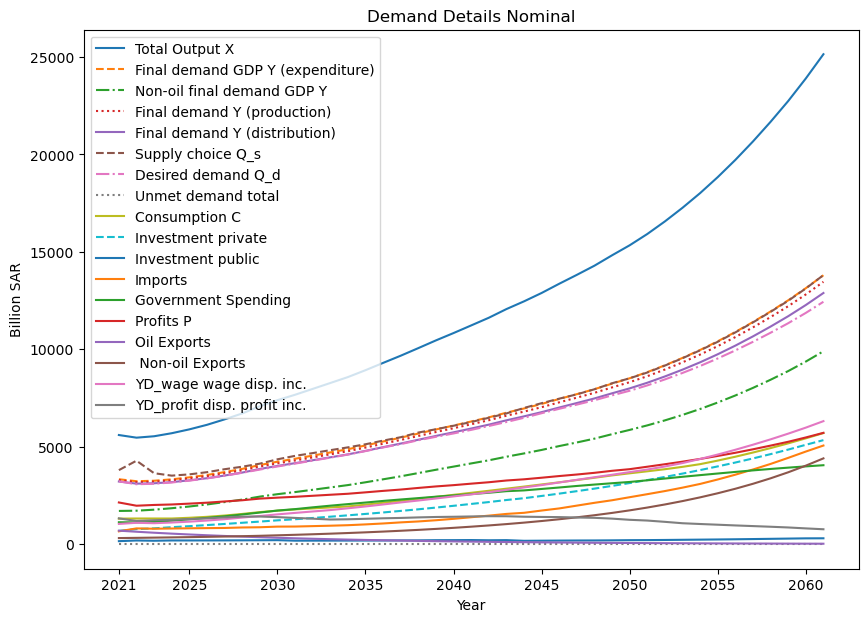

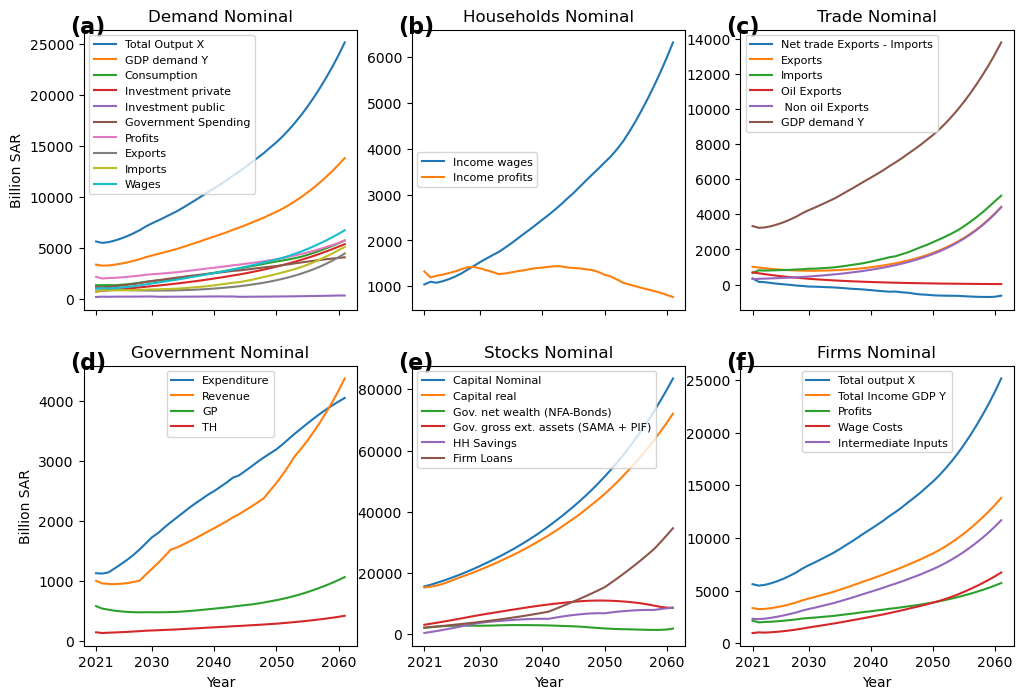

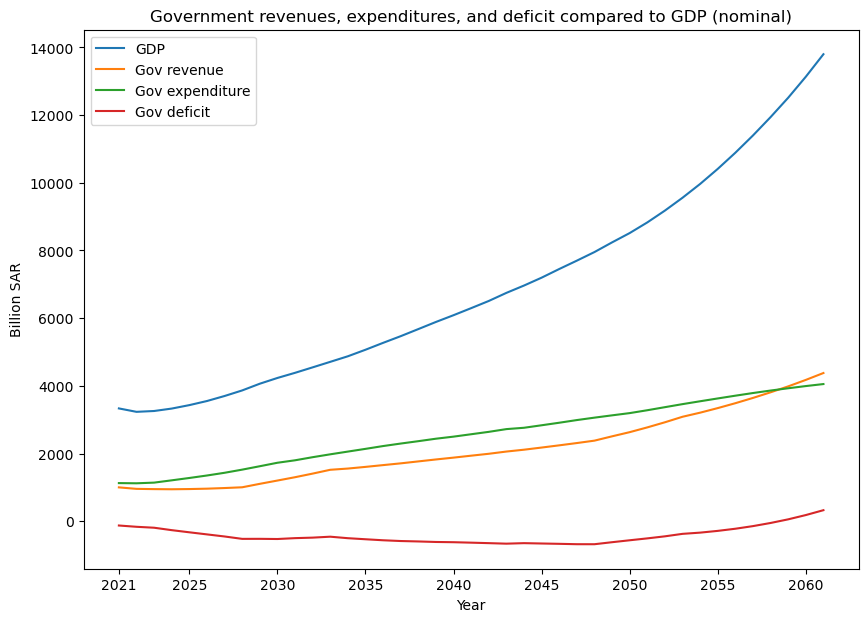

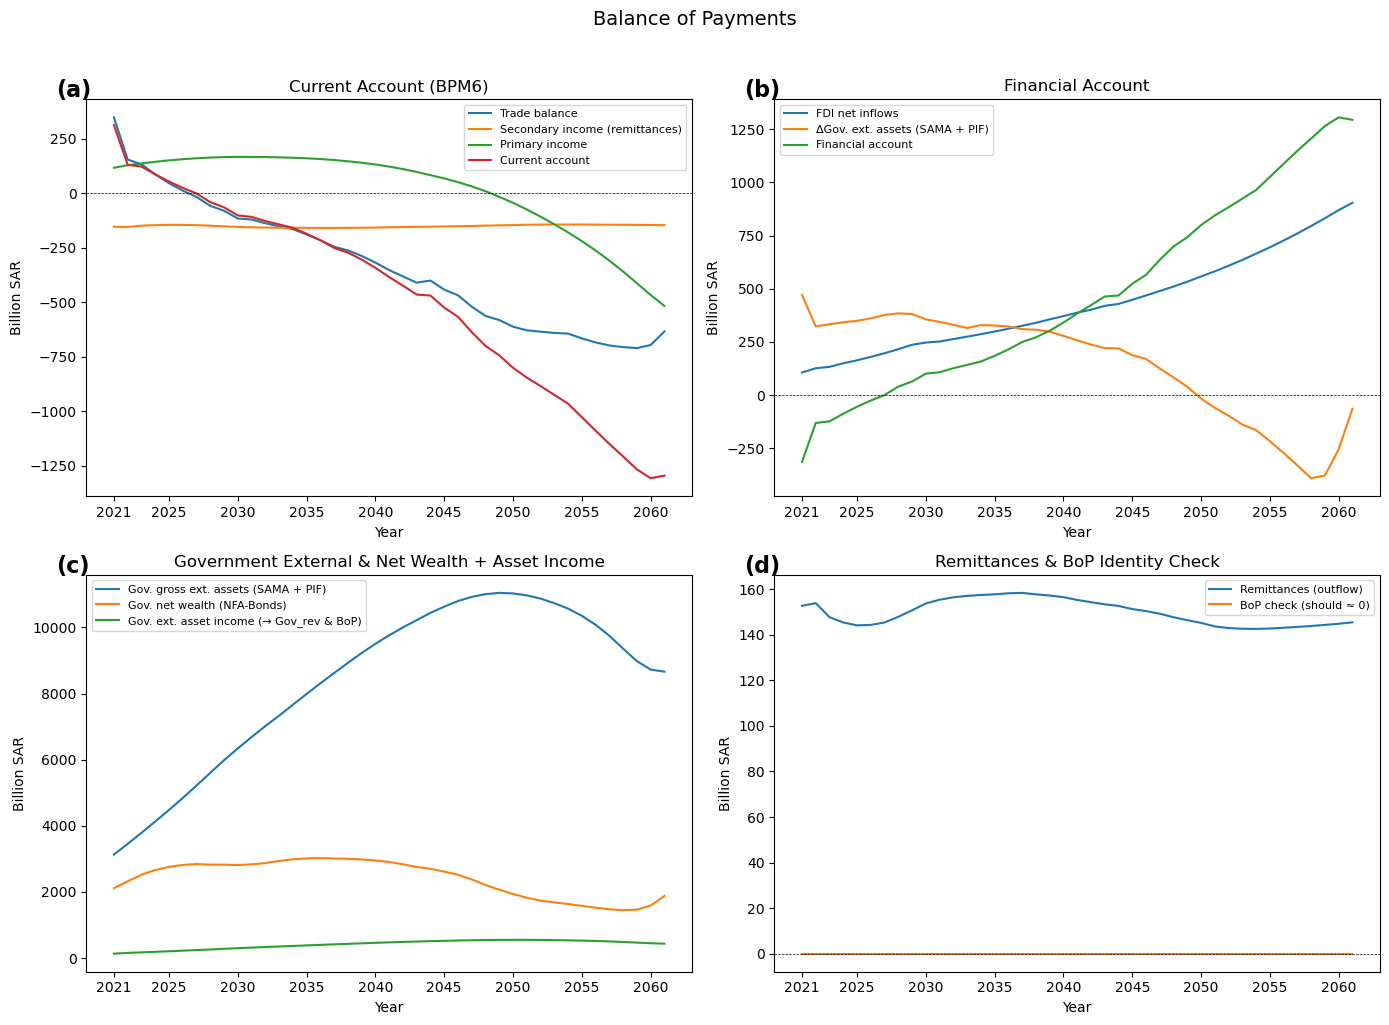

In [7]:
# Display Macro plots
plots = post.create_macro_graphs(results)

## Water results: Plots

## Sectoral results: Plots

Sector numbers and names in the model
Sector 0: Crop and animal production, hunting and related service activities
Sector 1: Forestry and logging
Sector 2: Fishing and aquaculture
Sector 3: Mining of coal and lignite
Sector 4: Extraction of crude petroleum and natural gas
Sector 5: Mining of metal ores
Sector 6: Other mining and quarrying activities
Sector 7: Mining support service activities
Sector 8: Manufacture of food products
Sector 9: Manufacture of beverages
Sector 10: Manufacture of tobacco products
Sector 11: Manufacture of textiles
Sector 12: Manufacture of wearing apparel
Sector 13: Manufacture of leather and related products
Sector 14: Manufacture of woods, wood products and cork except furniture
Sector 15: Manufacture of paper and paper products
Sector 16: Printing and reproduction of recorded media
Sector 17: Manufacture of coke and refined petroleum products
Sector 18: Manufacture of chemicals and chemical products
Sector 19: Manufacture of basic pharmaceutical products 

c:\Users\MIESSMG\KEN_model_public\model\postprocessing.py:861: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(15, 8))


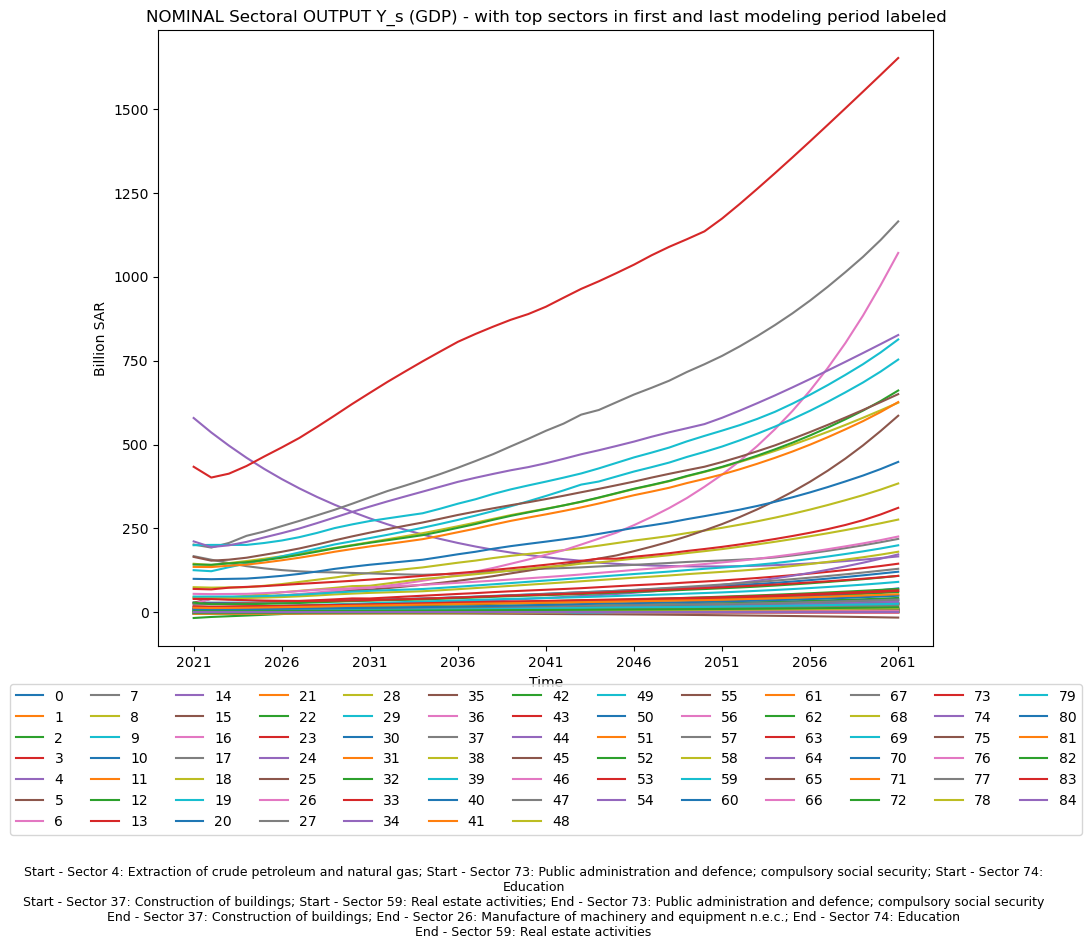

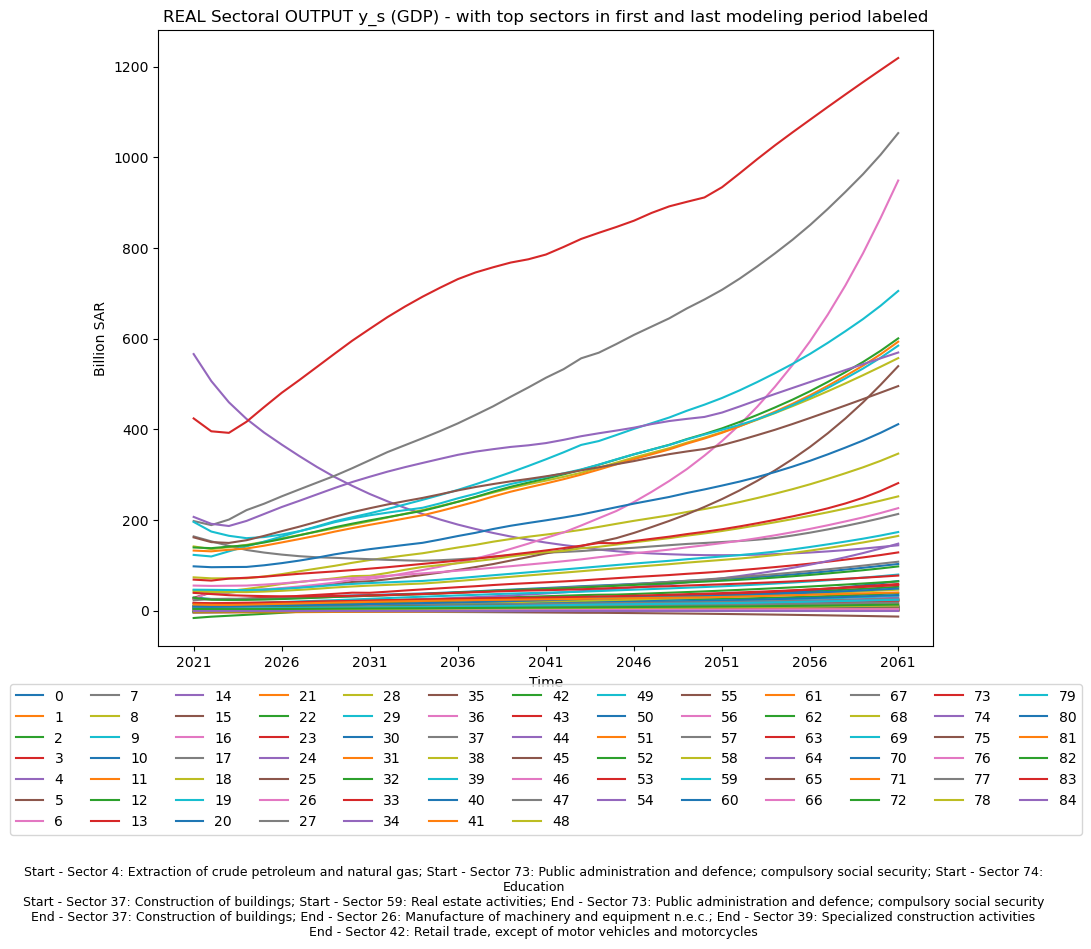

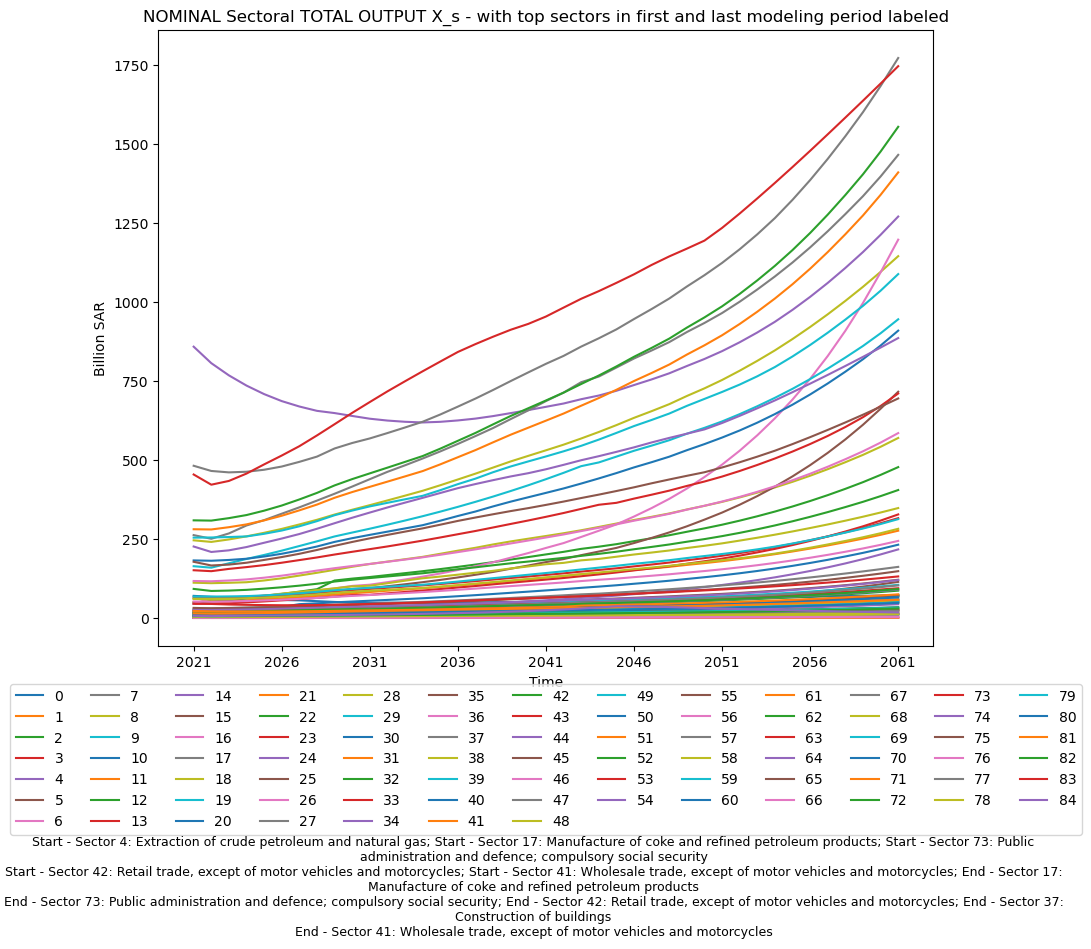

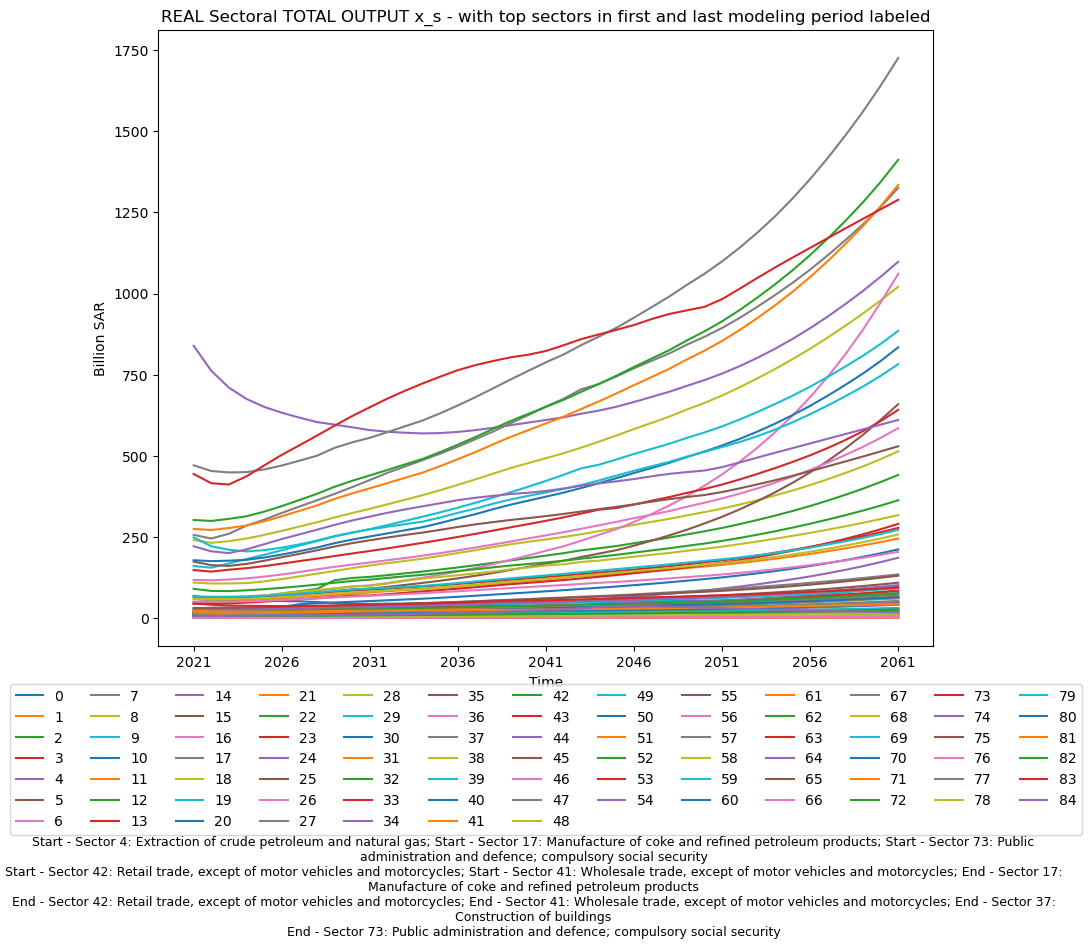

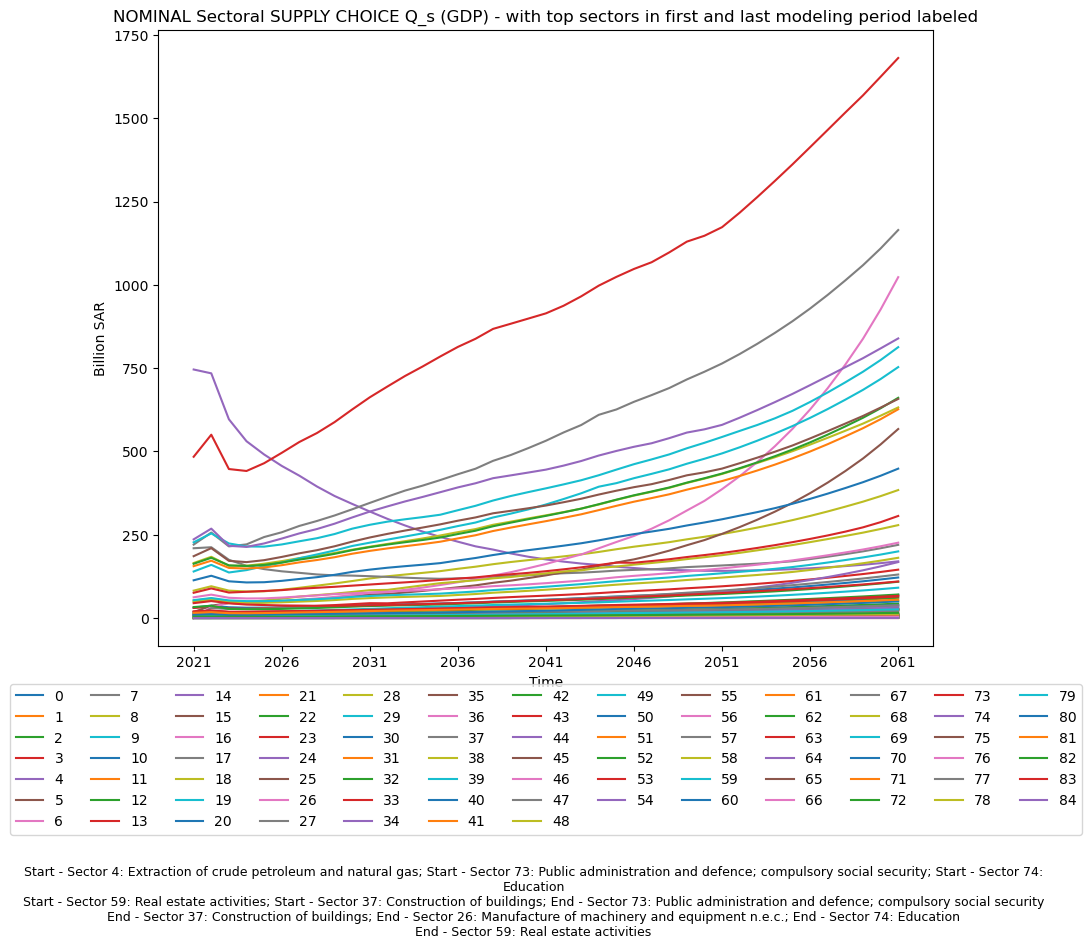

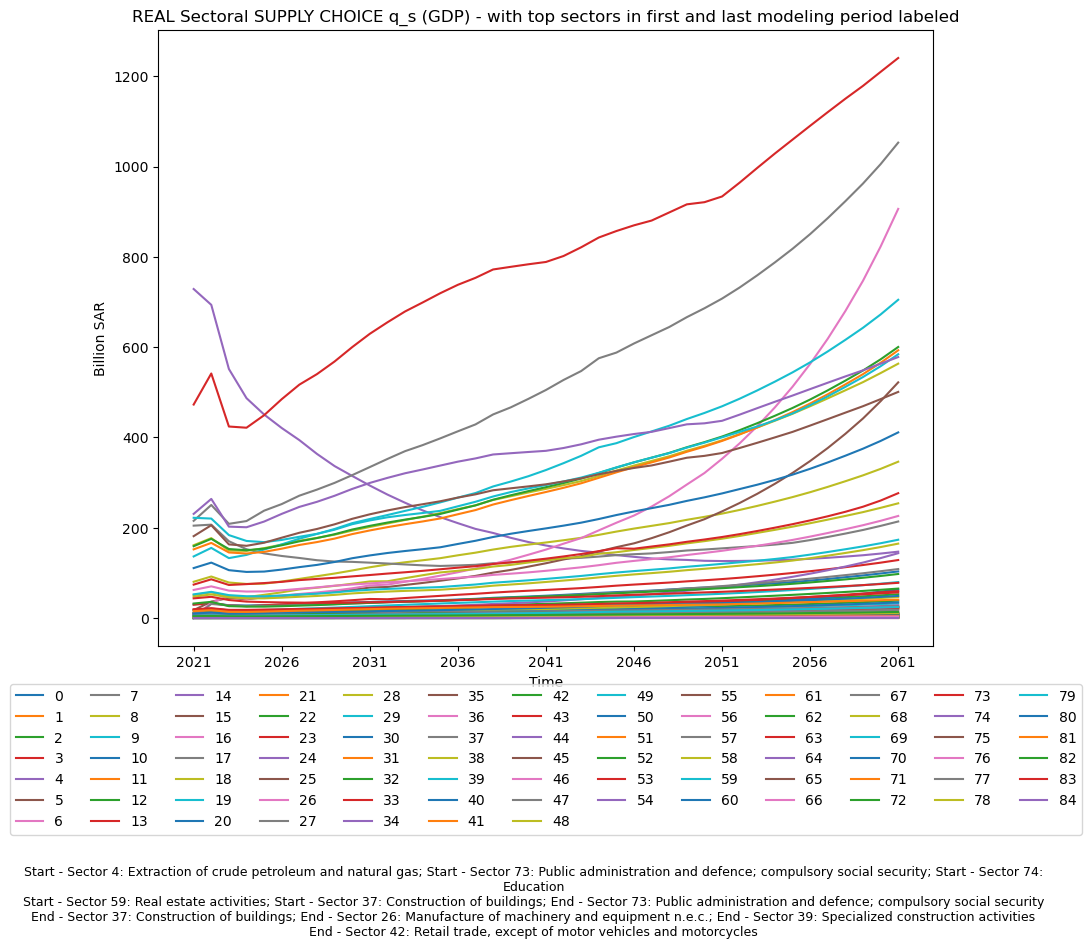

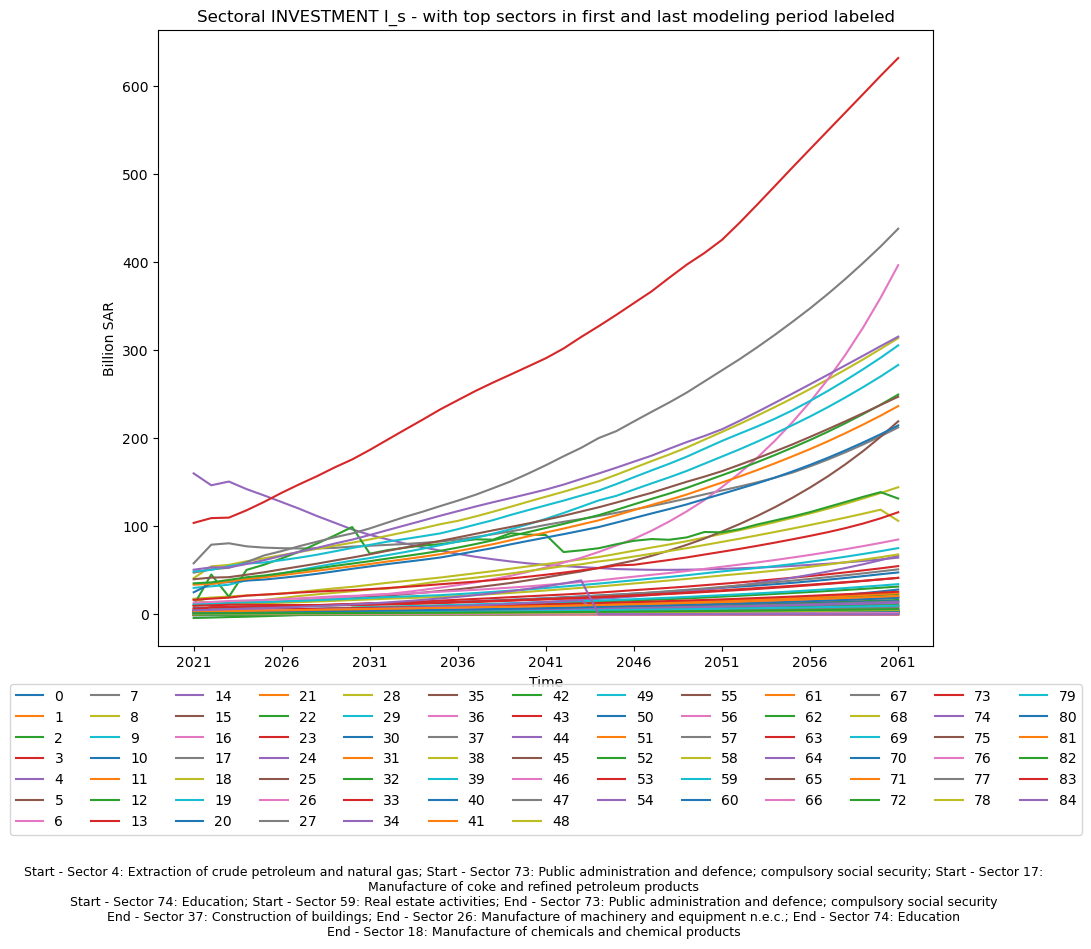

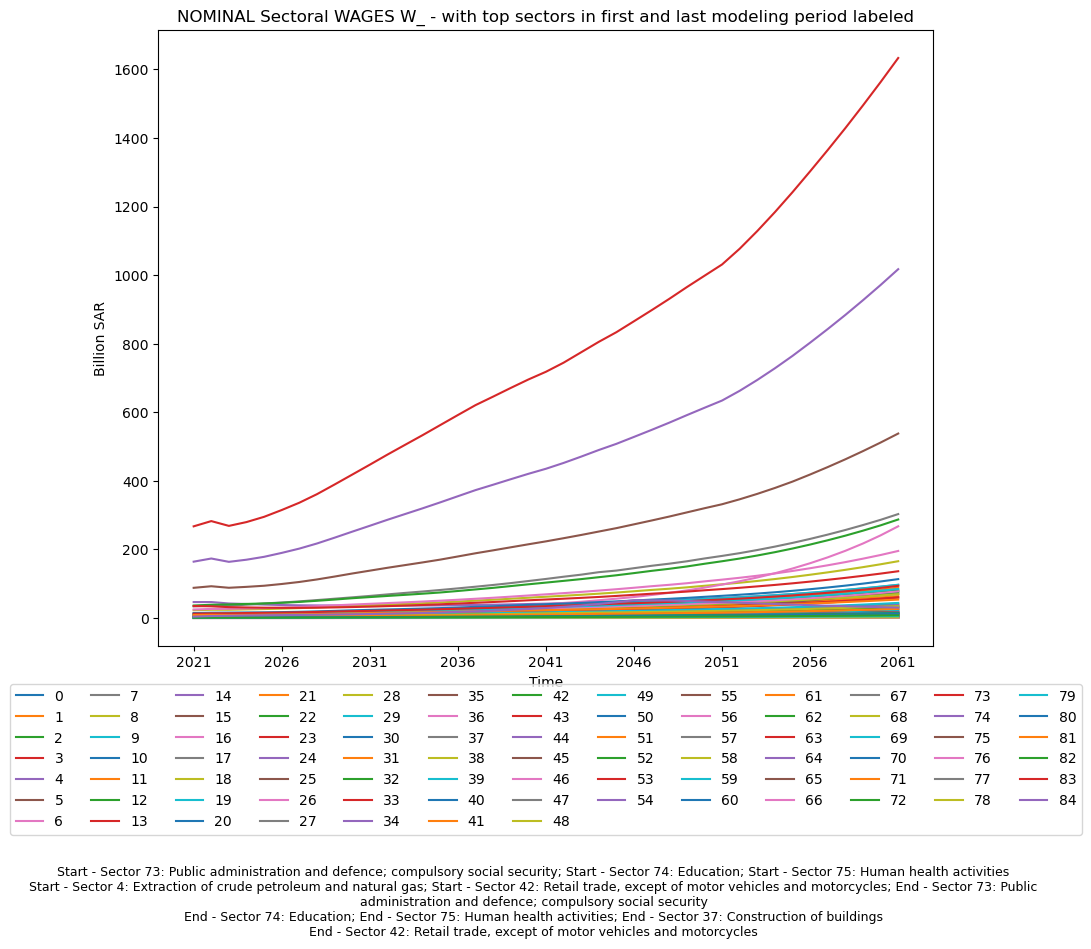

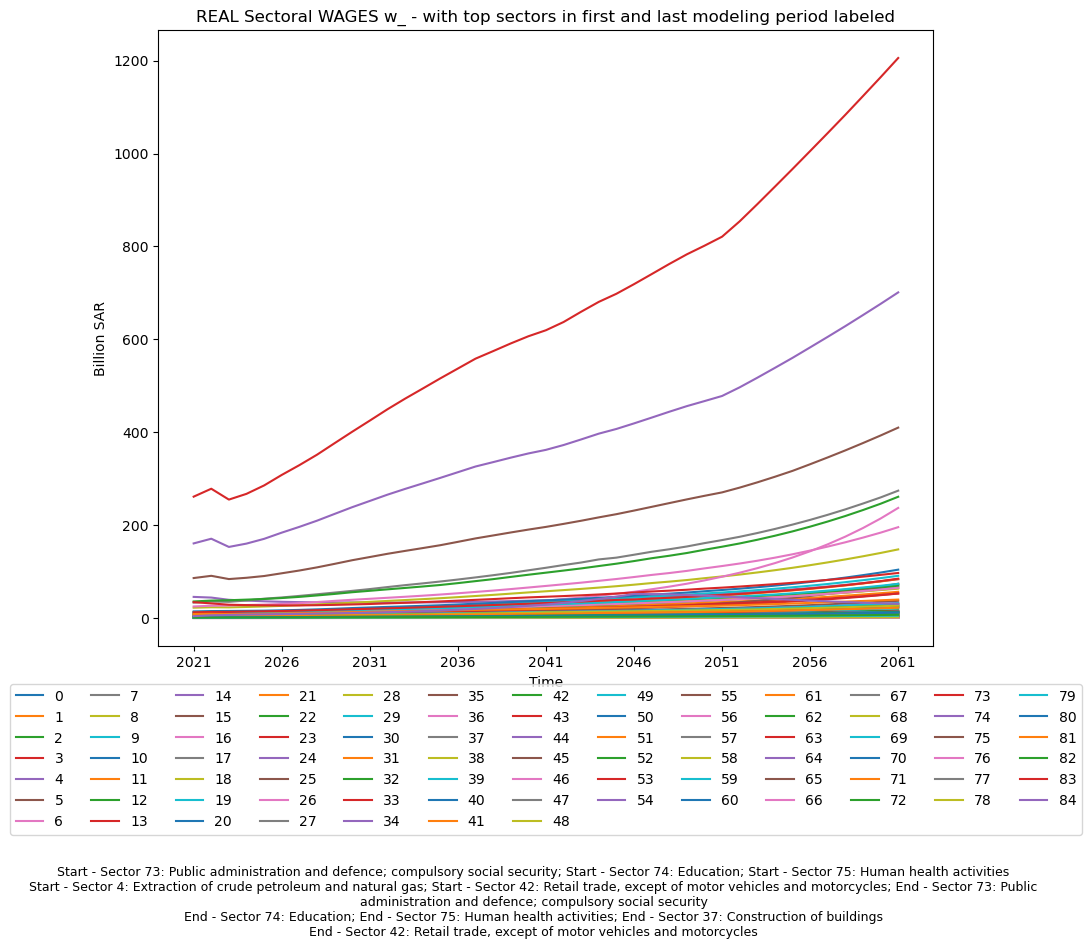

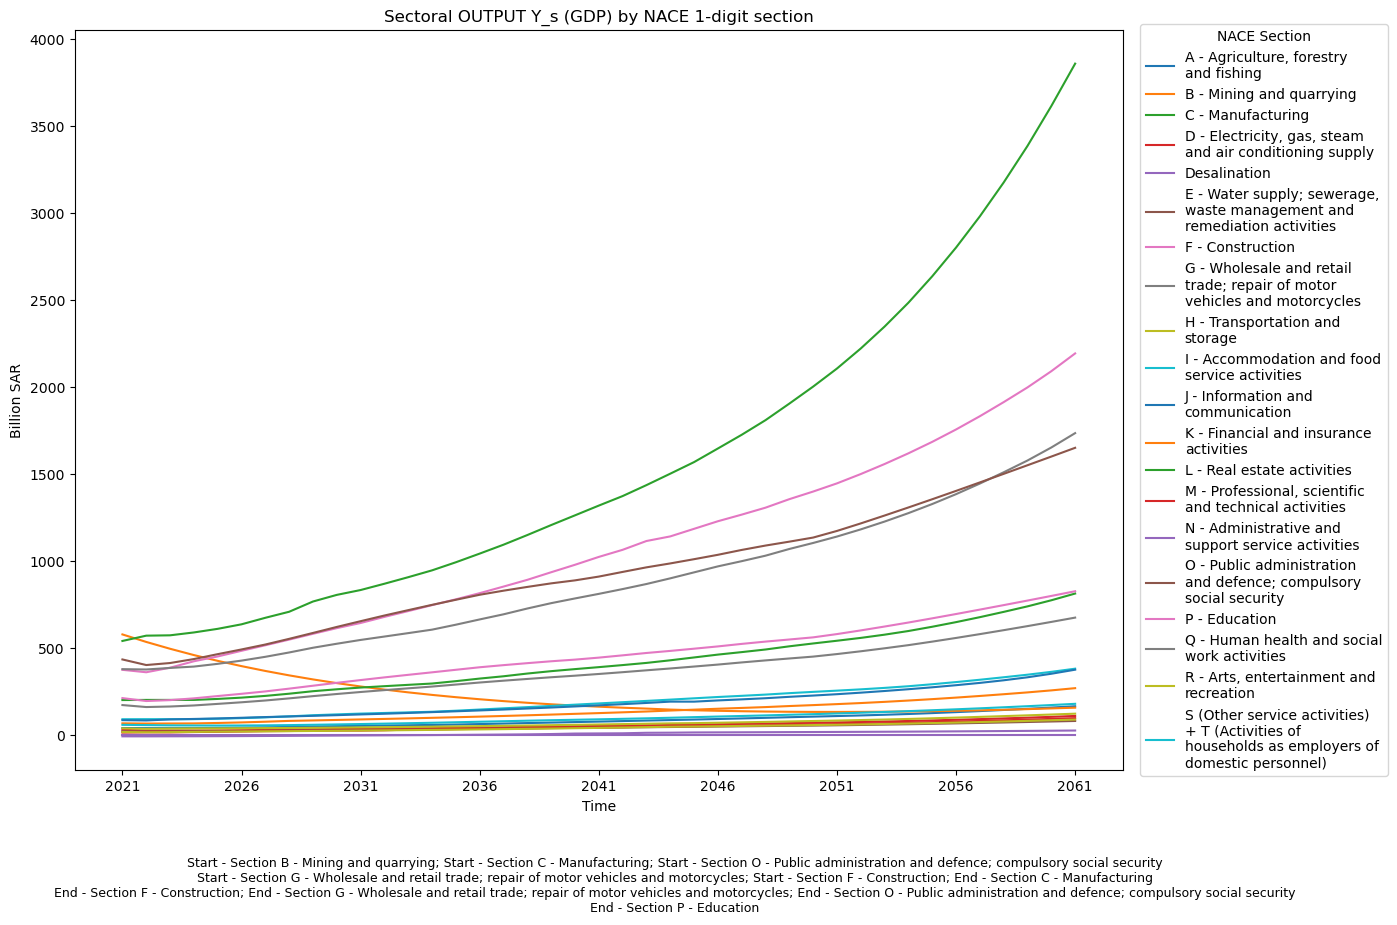

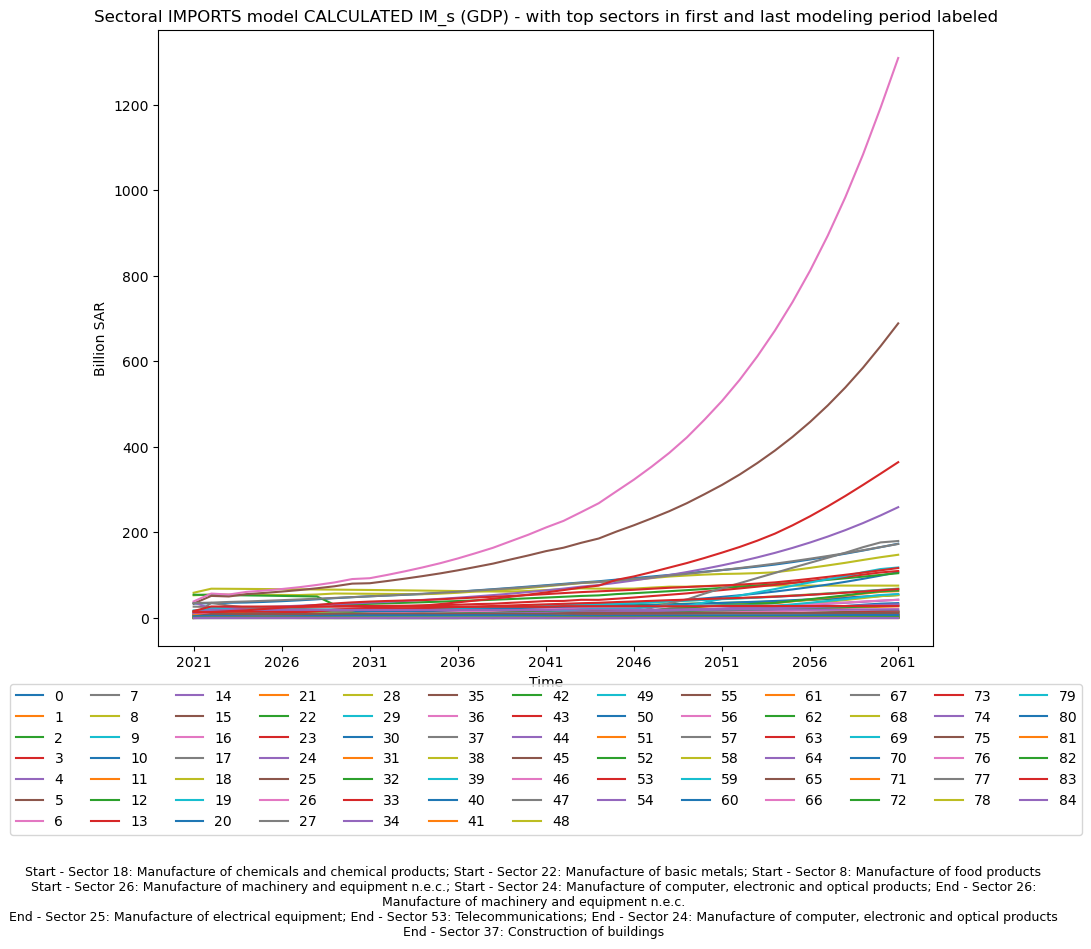

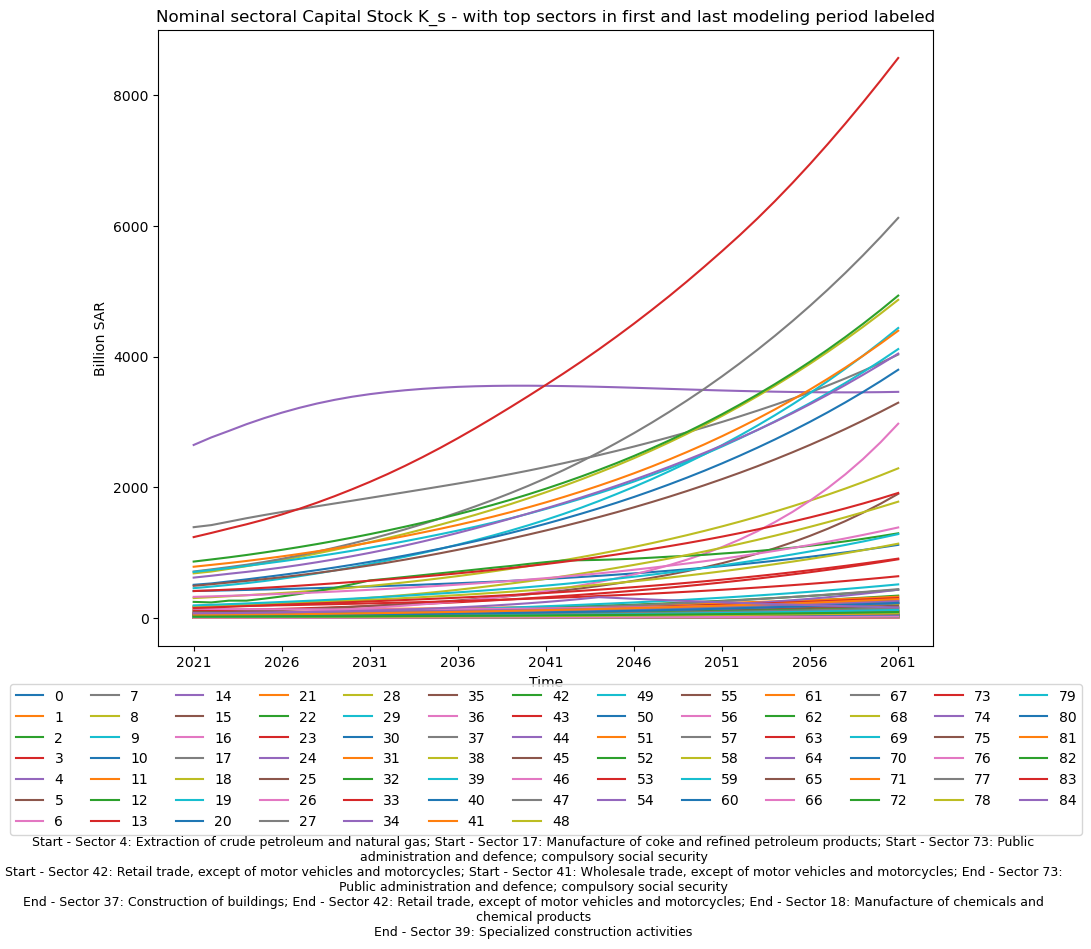

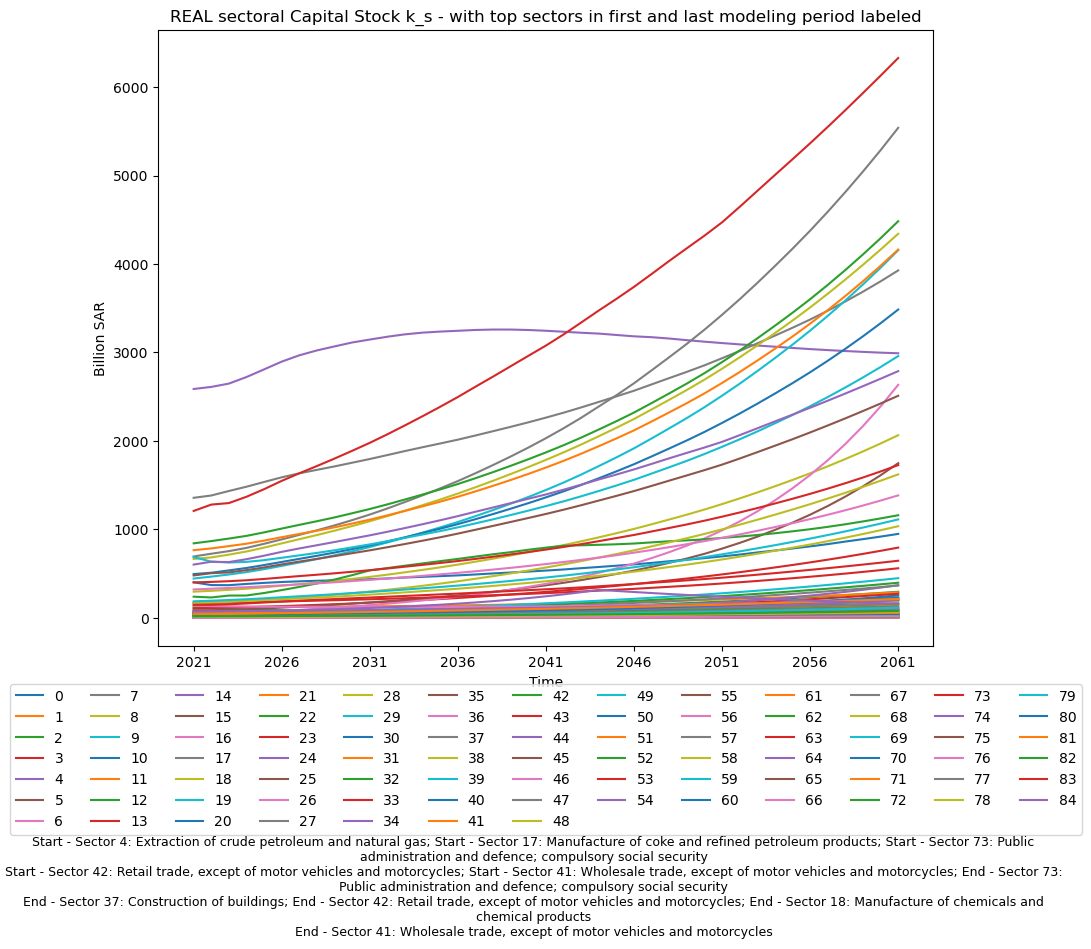

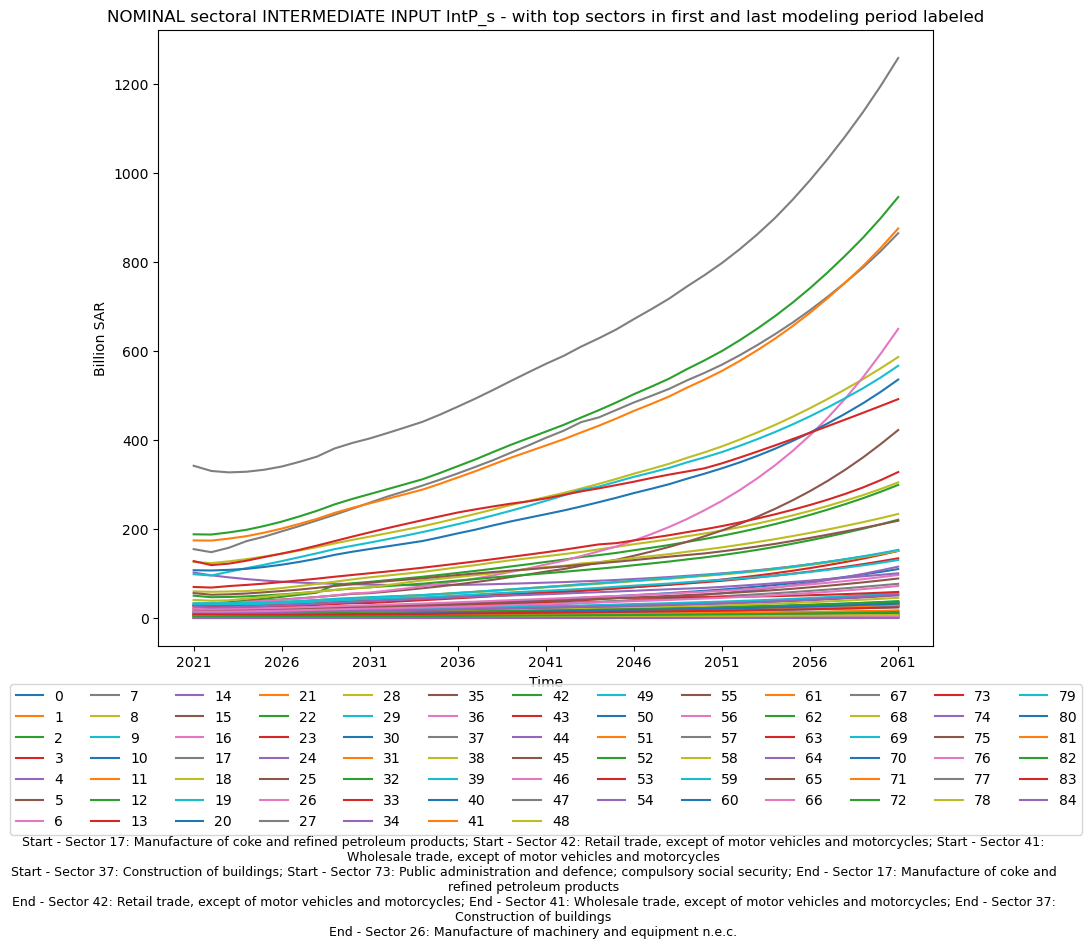

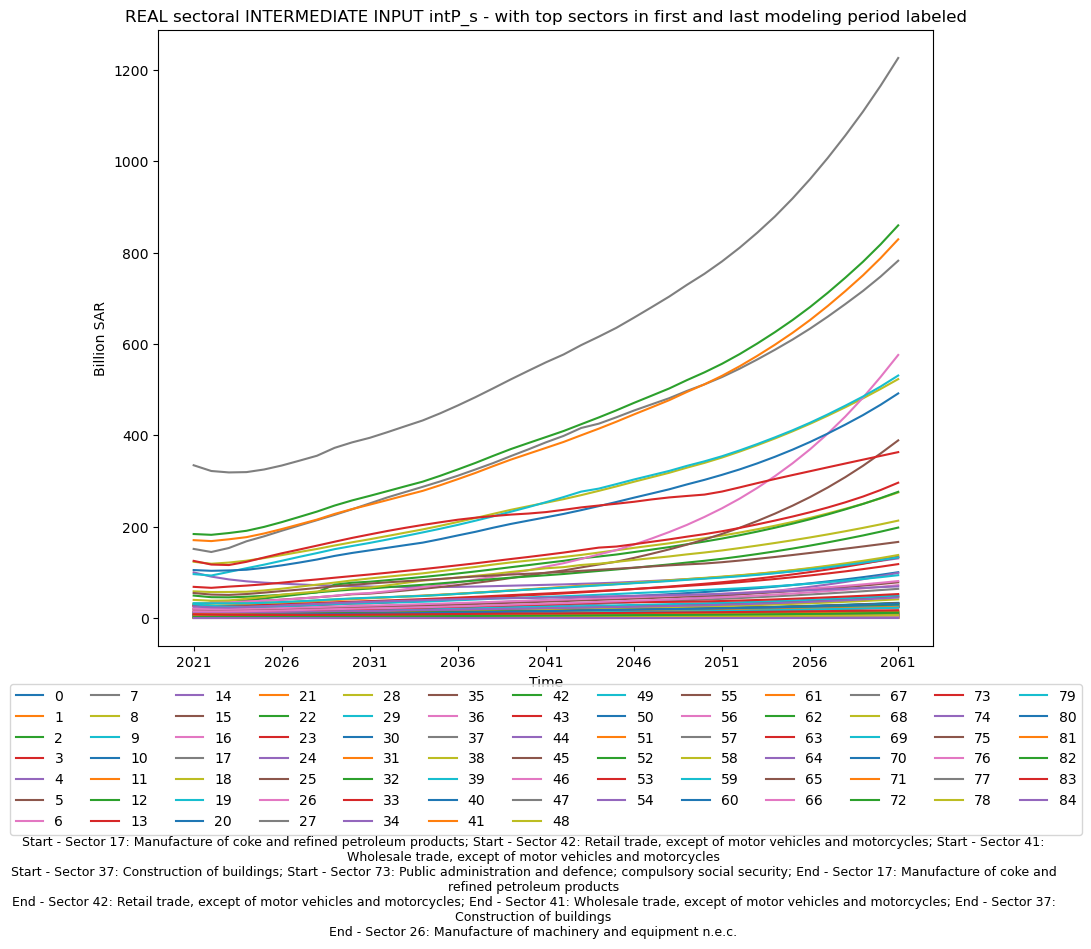

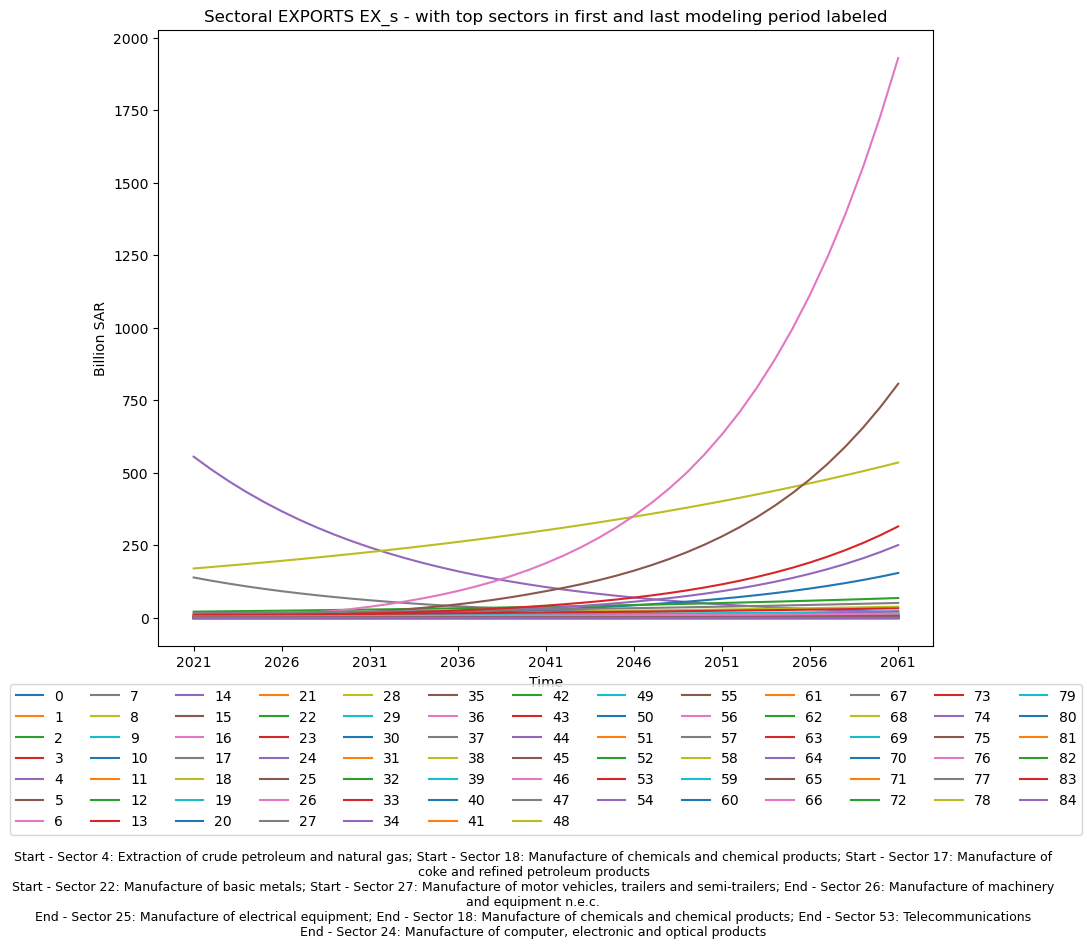

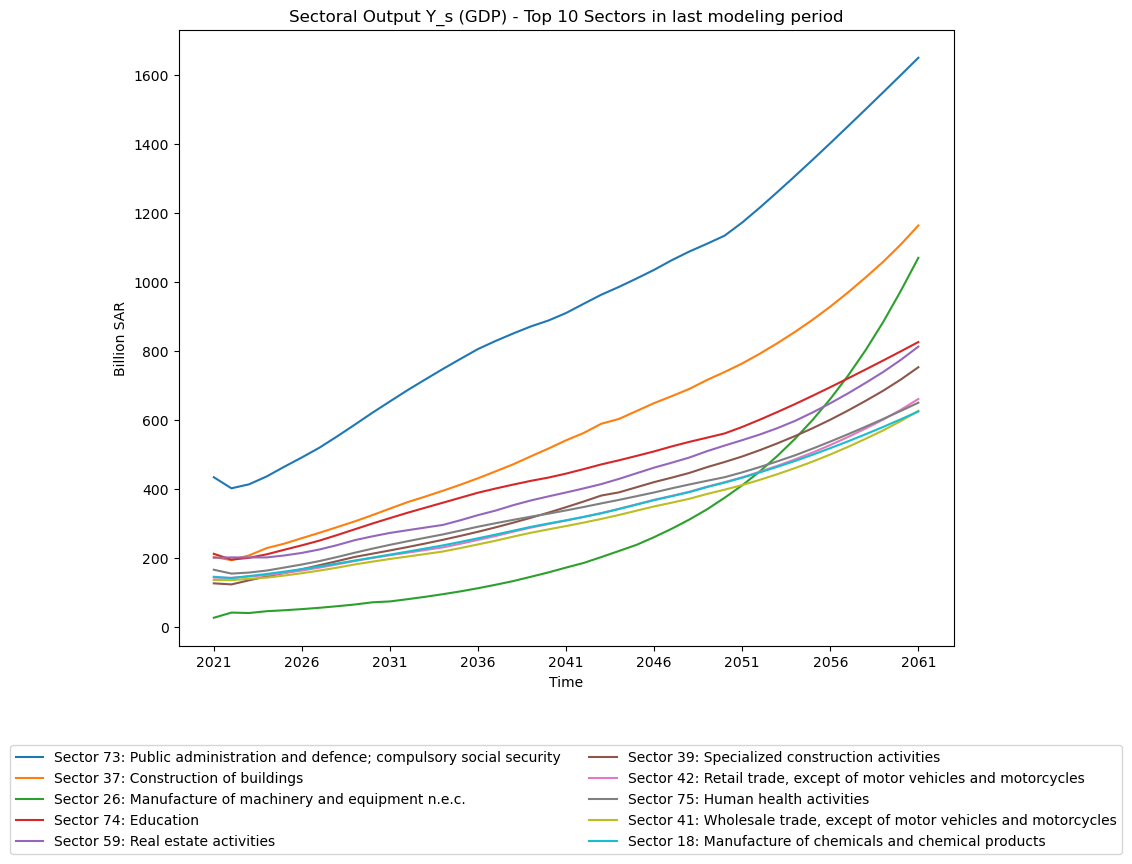

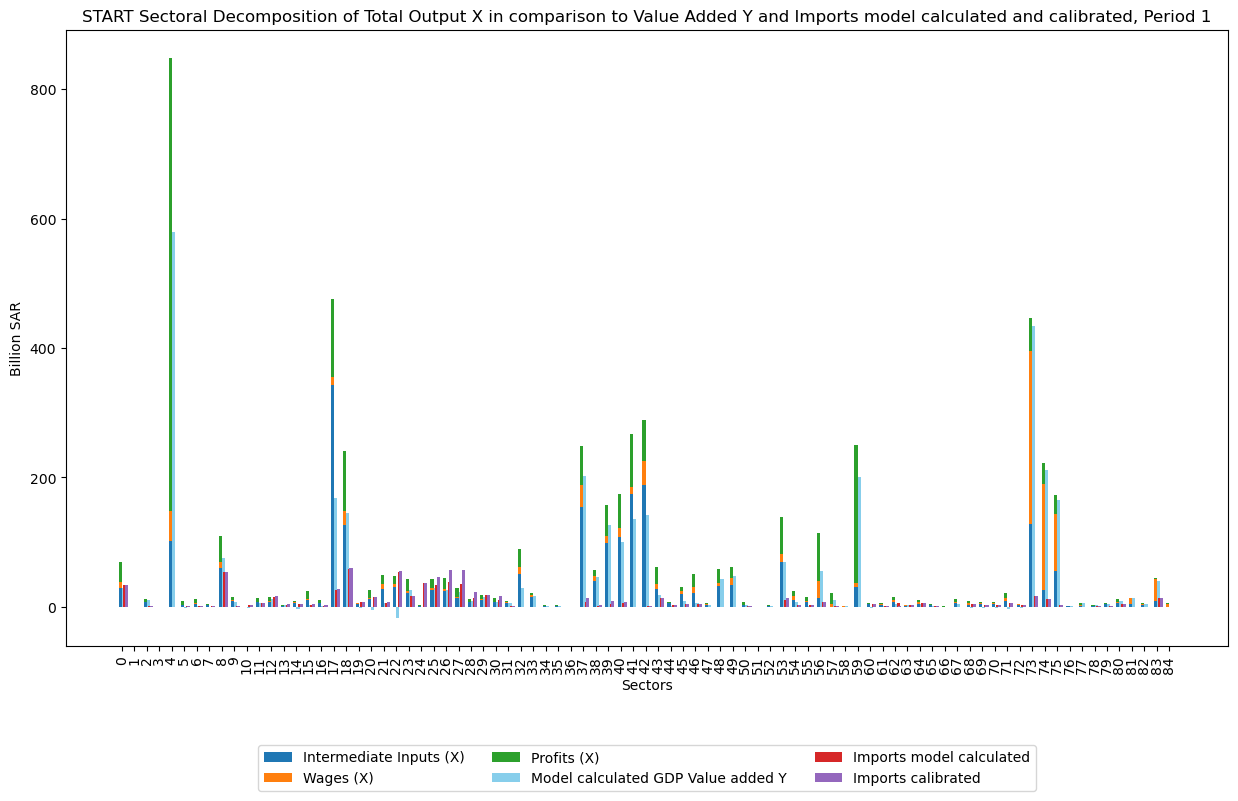

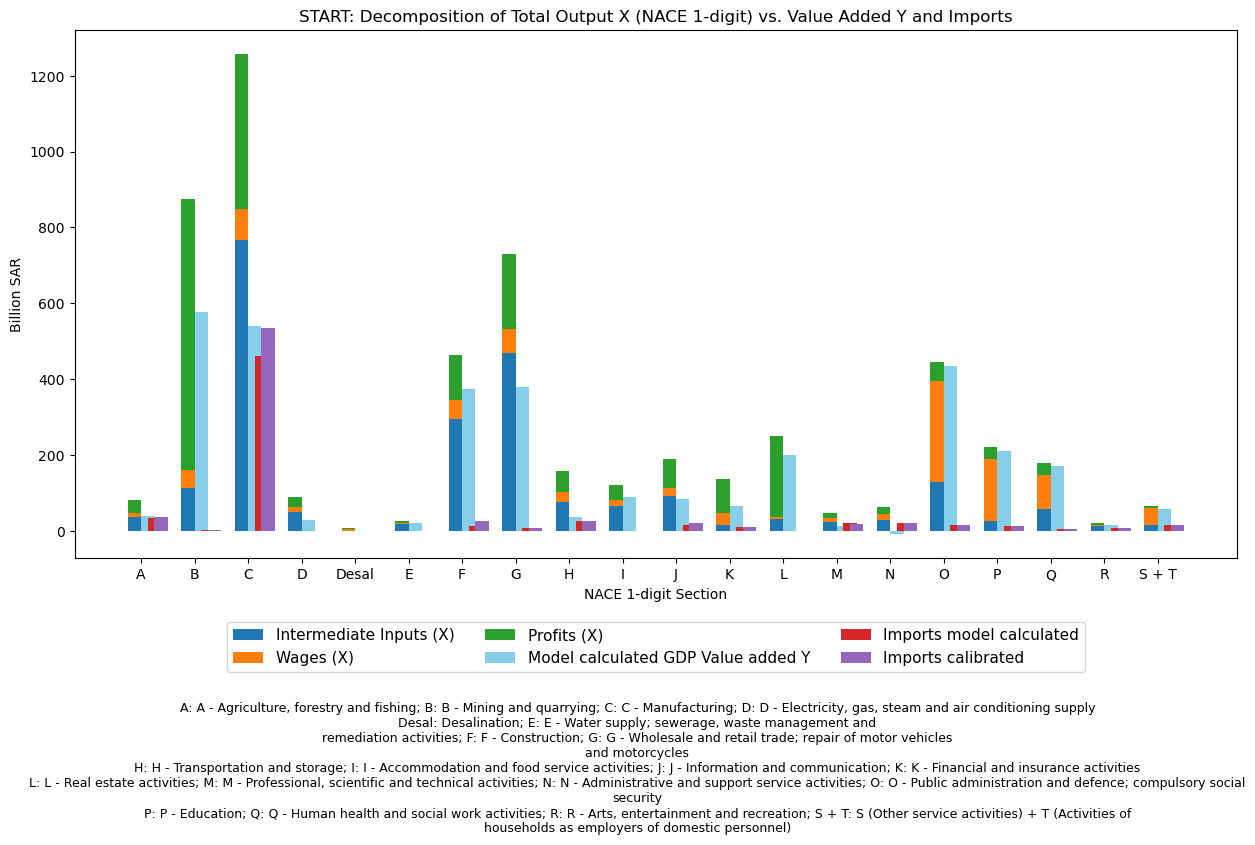

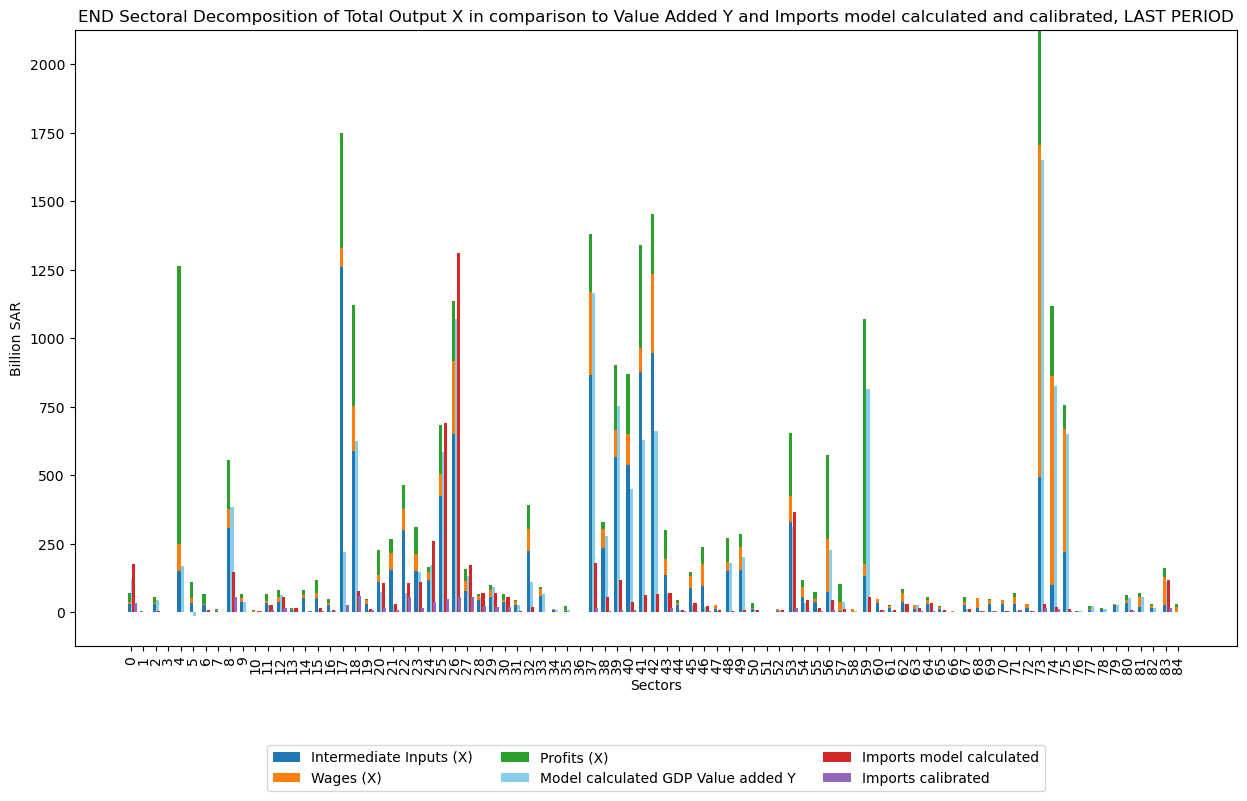

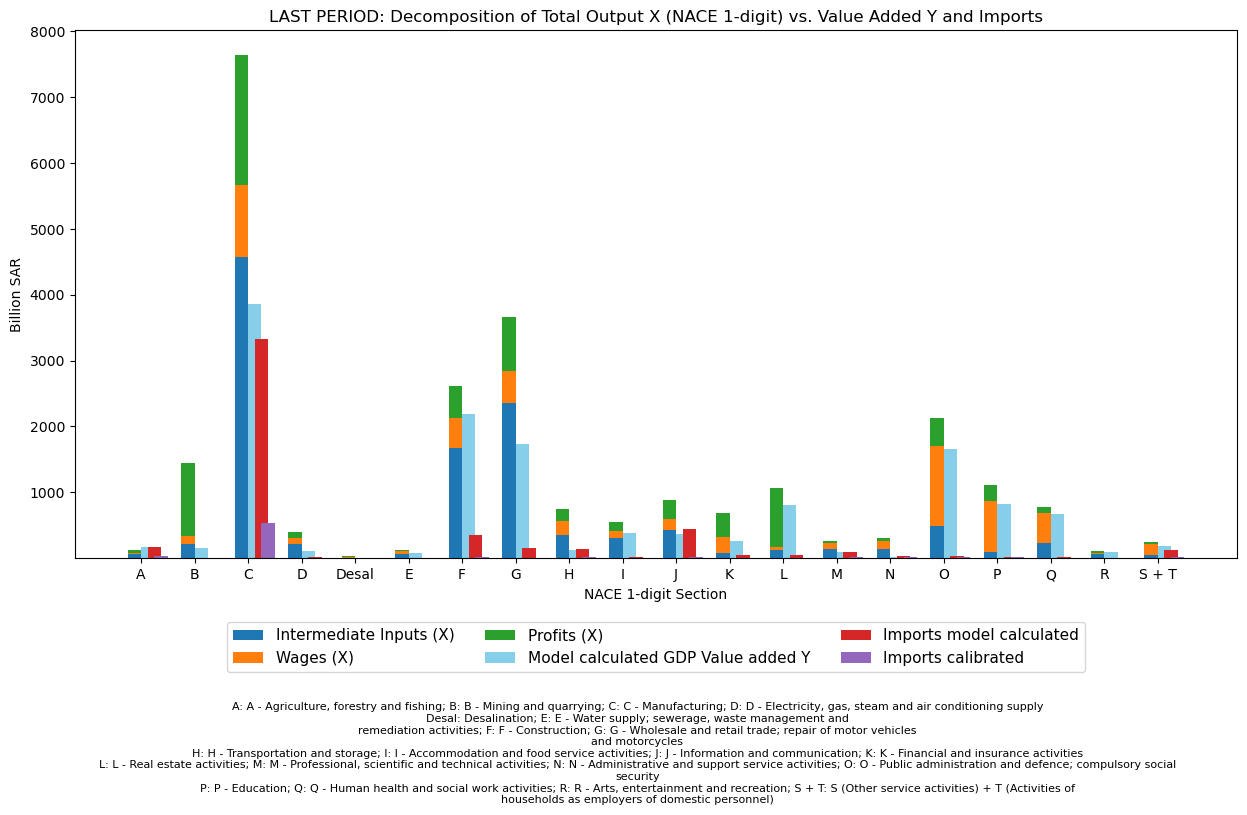

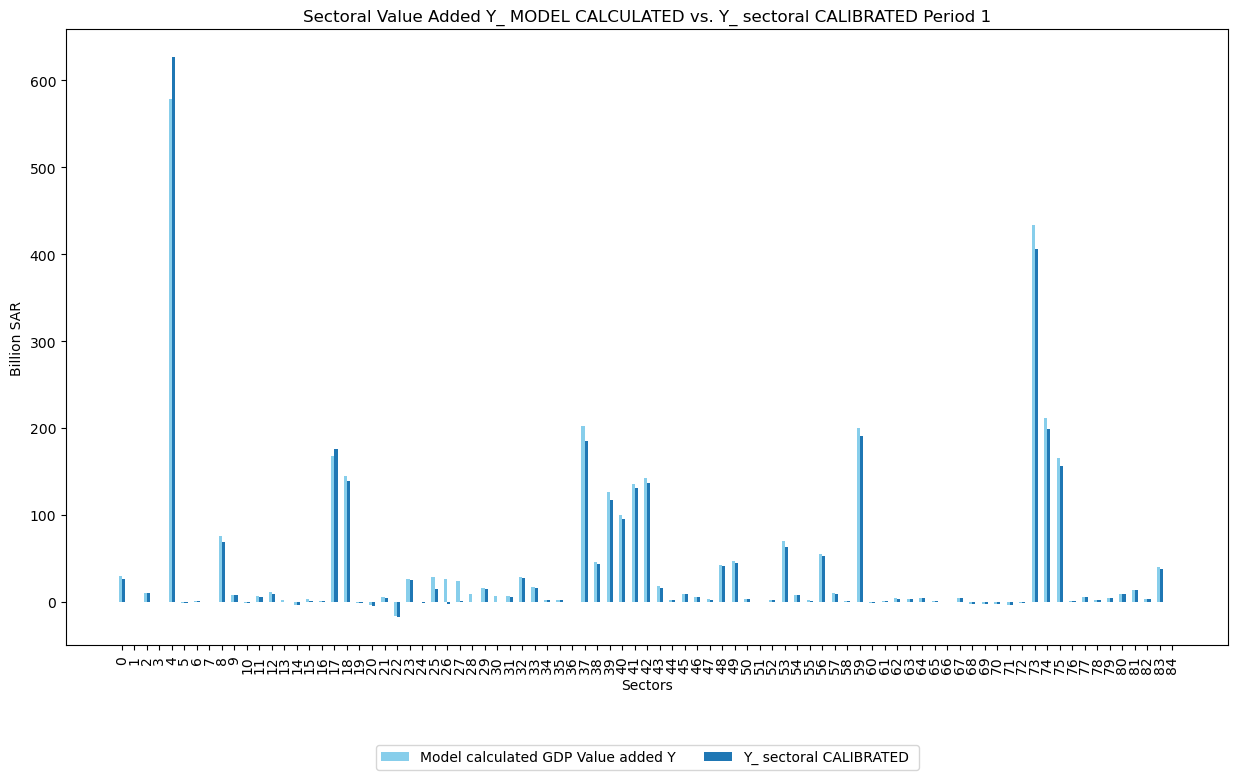

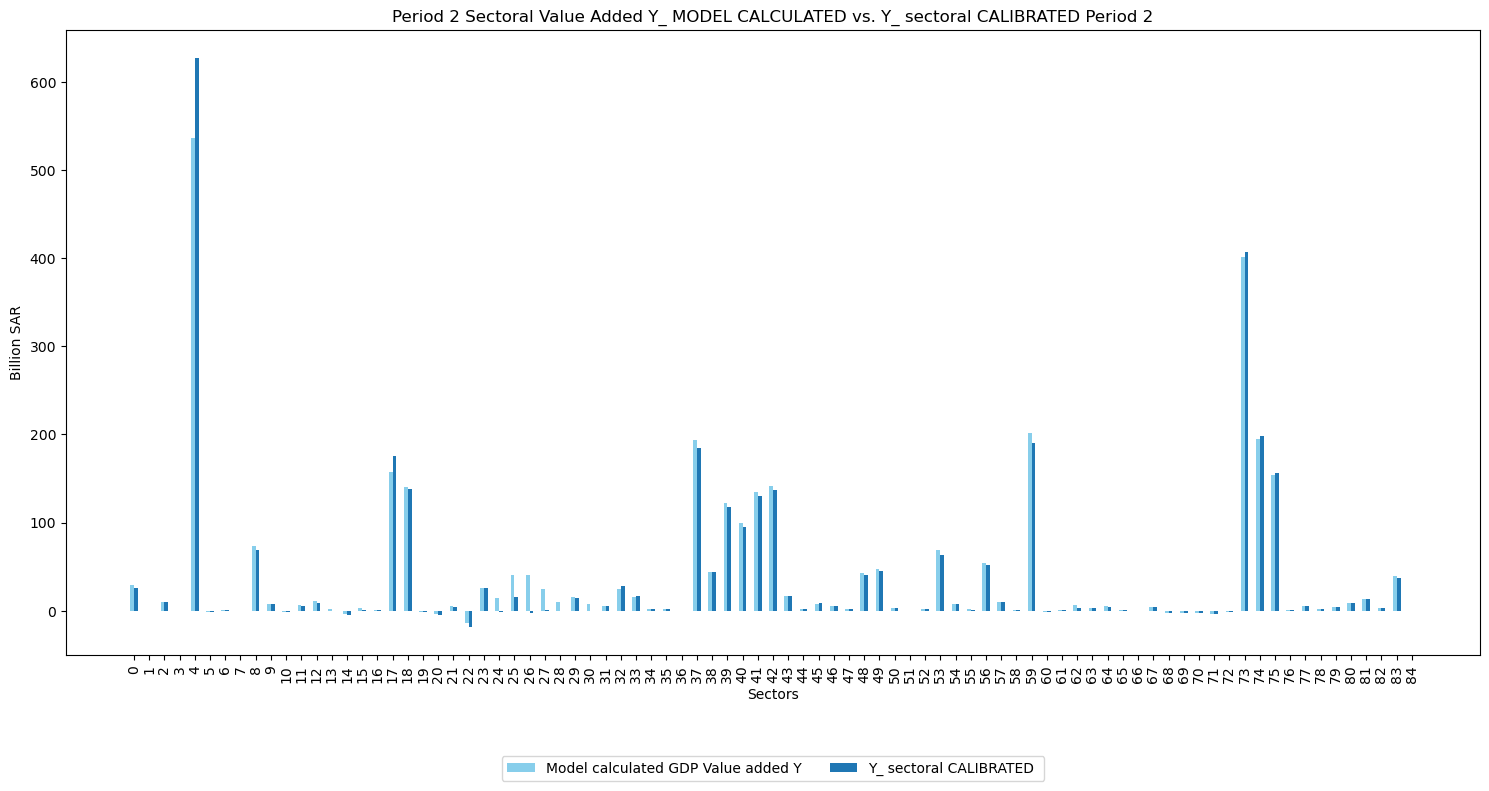

In [8]:
print("Sector numbers and names in the model")
sectors = parameters_calibrated.sectors
# Iterate over the sectors and their indices
for index, sector in enumerate(sectors):
    print(f"Sector {index}: {sector}")
sector_notes = [f"Sector {index}: {sector}" for index, sector in enumerate(parameters_calibrated.sectors)]
# Display Sectoral plots
##################################################################
plots = post.create_sectoral_graphs(results)
##################################################################
# Additional specific plots
# plots = post.create_detailed_sectoral_graphs(results)

## Energy results: Plots

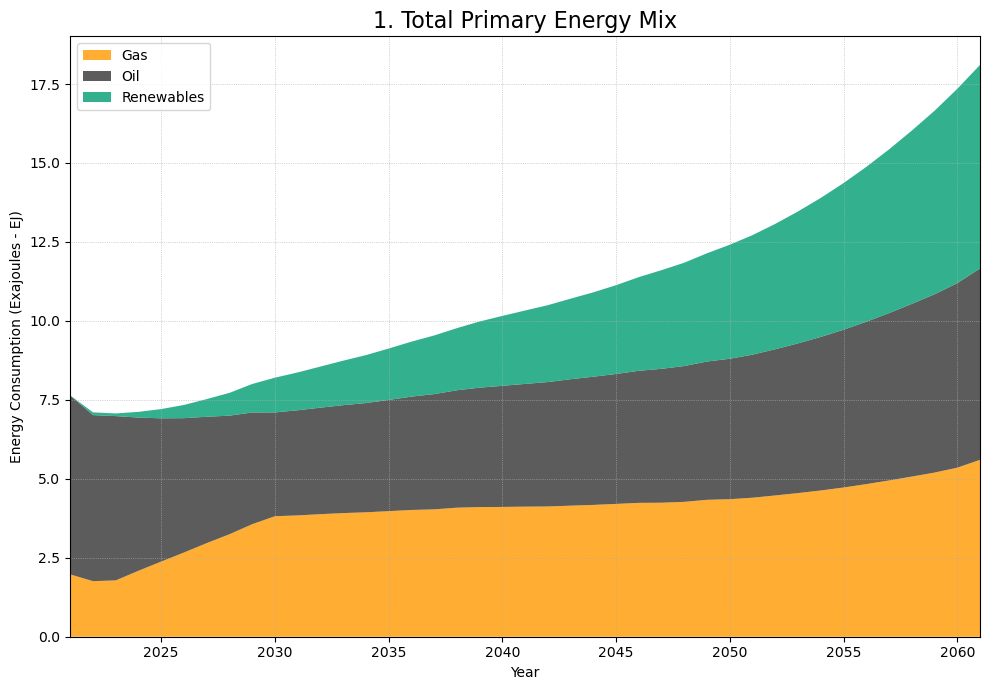


--- 5-Year Renewable Energy Investment & Share ---
Year 2025: Share = 18.7%, Annual Investment = 36.52 Billion SAR
Year 2030: Share = 50.5%, Annual Investment = 72.45 Billion SAR
Year 2035: Share = 56.4%, Annual Investment = 50.53 Billion SAR
Year 2040: Share = 62.9%, Annual Investment = 59.66 Billion SAR
Year 2045: Share = 68.0%, Annual Investment = 43.68 Billion SAR
Year 2050: Share = 73.8%, Annual Investment = 51.24 Billion SAR
Year 2055: Share = 78.6%, Annual Investment = 60.44 Billion SAR
Year 2060: Share = 83.6%, Annual Investment = 75.50 Billion SAR


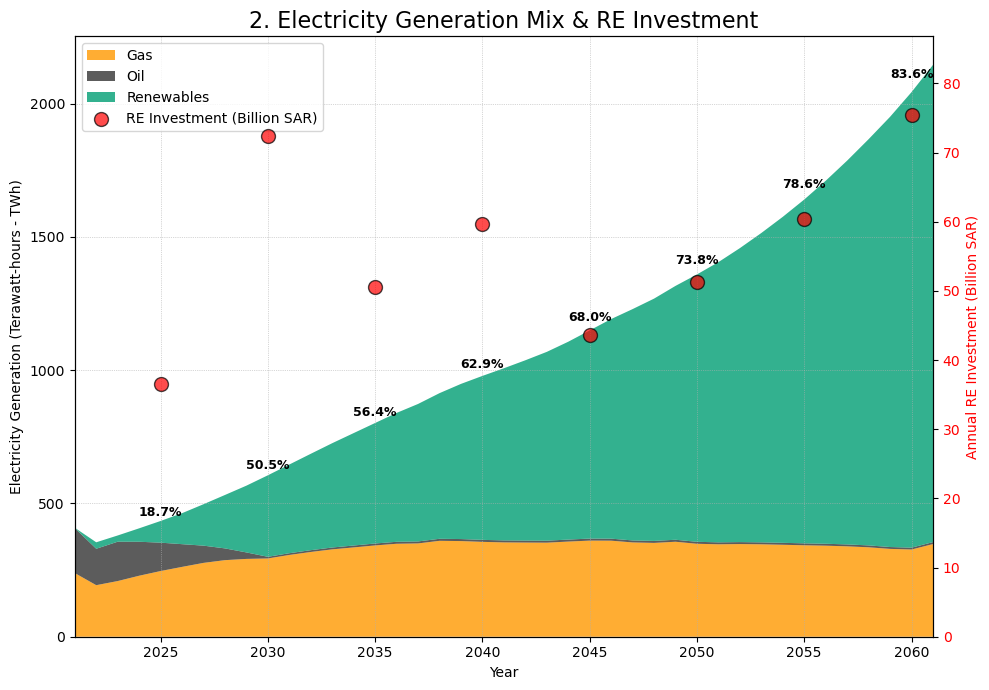

In [9]:
# Energy plots
post_energy.plot_primary_energy_mix(results)
post_energy.plot_electricity_generation_mix(results)
# post_energy.plot_energy_investments(results)


## Authorship of model components and paper sections

Michael Miess (all model components and paper sections): Conceptualization (including methodology of the model), data curation, formal analysis, investigation, methodology, software (model architecture and code), supervision, validation, visualization, writing – original draft, writing – review and editing. 

Ansir Ilyas (focus on energy model components and paper sections): Conceptualization, data curation, formal analysis, investigation, software (model code), validation, visualization, writing – original draft, writing – review and editing. 

Dan Wang (focus on water model components and paper sections): Conceptualization, data curation, formal analysis, investigation, software (model code), validation, visualization, writing – original draft, writing – review and editing. 

Asjad Naqvi: Conceptualization, methodology, investigation, validation, writing – review and editing. 

Yoshihide Wada: Conceptualization (including initial conception of the project and study), funding acquisition, project administration, resources, supervision, investigation, validation, writing – review and editing.